# Лабоаторная работа 2
## Линейная регрессия

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1.** Загрузите датасет с успеваемостью студентов (https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

   Изучите признаки: их шкалу, тип данных, наличие пропусков, распределение. Нашей целевой переменной будет последняя колонка - Performance Index

In [56]:
data = pd.read_csv('Student_Performance.csv')
print("=" * 60)
print(data.info())
print("=" * 60)
print(data.describe())
print("=" * 60)
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Переведите все фичи в числа и сохраните в переменной Х формата np.array. Целевую колонку сохраните в массив y. Для превращения в массив можно использовать df.values. Постройте корреляционную матрицу (это можно сделать как за счет numpy, так и с исходным датафреймом, если выделить из него только числовые колонки)

Разбейте данные на тренировочный и тестовый наборы в отношении 80:20

In [57]:

# перевел все фичи в числа
data['Extracurricular Activities'] = data['Extracurricular Activities'].apply(lambda x: 1 if x == 'Yes' else 0)

X = data.drop('Performance Index', axis=1).values
y = data['Performance Index'].values

numeric_data = data.drop('Performance Index', axis=1)
correction_matrix = numeric_data.corr()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)


Размер X_train: (8000, 5)
Размер X_test: (2000, 5)
Размер y_train: (8000,)
Размер y_test: (2000,)


**2.** На основе базовых классов из sklearn напишите свою линейную регрессию, где коэффициенты находятся с помощью псевдообратной матрицы. Не забудьте про свободный член! Он должен откуда-то появиться.
   $$ w = (X^TX)^{-1} X^T y$$

Второй регрессор напишите с градиентным спуском (мы тут не будем рассматривать стохастический и мини-батч, хотя, если интересно, можете и их заимплементить). Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. По результатам измышлений допишите еще входных параметров в метод \__init__. В качестве функции потерь выберем MSE. В матричной записи она будет выглядеть как $\frac{1}{N}(Xw - y)^T(Xw - y).$ Дифференцируя ее по $w$, получим $$\frac{2}{N} X^T(Xw - y).$$ Формула с псевдообратной матрицей, кстати, получается, если приравнять это к 0 и выразить $w$.

Мы хотим двигаться в направлении, противоположном этому, т.е. эта величина, умноженная на скорость обучения (learning rate), отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, он войдет в lr, а вот убирать $N$, пожалуй, не стоит.

In [58]:
from sklearn.base import BaseEstimator, RegressorMixin

In [59]:
# напишите свою линейную регрессию, 
# где коэффициенты находятся с помощью псевдообратной матрицы
class PseudoInvRegressor(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.weights_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X] # [X|1], учли w0
        # $$ w = (X^TX)^{-1} X^T y$$
        self.weights_ = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
        return self
        
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        predictions = X_with_bias @ self.weights_
        return predictions #вектор предсказаний

In [60]:
# Второй регрессор напишите с градиентным спуском
class GradRegressor(BaseEstimator, RegressorMixin):
    # Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. 
    # По результатам измышлений допишите еще входных параметров в метод \__init__
    def __init__(self, learning_rate=0.001, n_iterations=1000, tolerance=1e-5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations # max количество итераций
        self.tolerance = tolerance
        self.weights_ = None
        self.loss_history_ = []
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        
        self.weights_ = np.random.randn(n_features)
        
        prev_loss = float('inf')
        
        for i in range(self.n_iterations): 
            # предсказание
            predications = X_with_bias @ self.weights_
            
            # считаем ошибку
            # $\frac{1}{N}(Xw - y)^T(Xw - y).$
            loss = np.mean((predications - y)**2)
            self.loss_history_.append(loss)
            
            if abs(prev_loss - loss) < self.tolerance:
                print(f"Остановка на {i+1}")
                break
            prev_loss = loss
            
            #  $$\frac{2}{N} X^T(Xw - y).$$ 
            gradient = (2 / n_samples) * X_with_bias.T @ (predications - y)
            # обновляем веса
            
            # Мы хотим двигаться в направлении, противоположном этому, 
            #т.е. эта величина, умноженная на скорость обучения (learning rate),
            # отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, 
            # он войдет в lr, а вот убирать $N$, пожалуй, не стоит.
            self.weights_ = self.weights_ - self.learning_rate * gradient
            
            if (i % 5 == 0):
                print(f"{i}: MSE = {loss}")
            
        return self
        
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_ #вектор предсказаний

Обучите оба регрессора на загруженных данных. Для второго регрессора придется поэкспериментировать со скоростью и продолжительностью обучения. Постройте график ошибок. 

MSE для PseudoInvRegressor: 4.0826
Веса: [-33.92194622   2.85248393   1.0169882    0.60861668   0.47694148
   0.19183144]
0: MSE = 1167.4944885206132
5: MSE = 112.88828472597291
MSE для GradRegressor: 4.0826
Веса: [-33.92194622   2.85248393   1.0169882    0.60861668   0.47694148
   0.19183144]


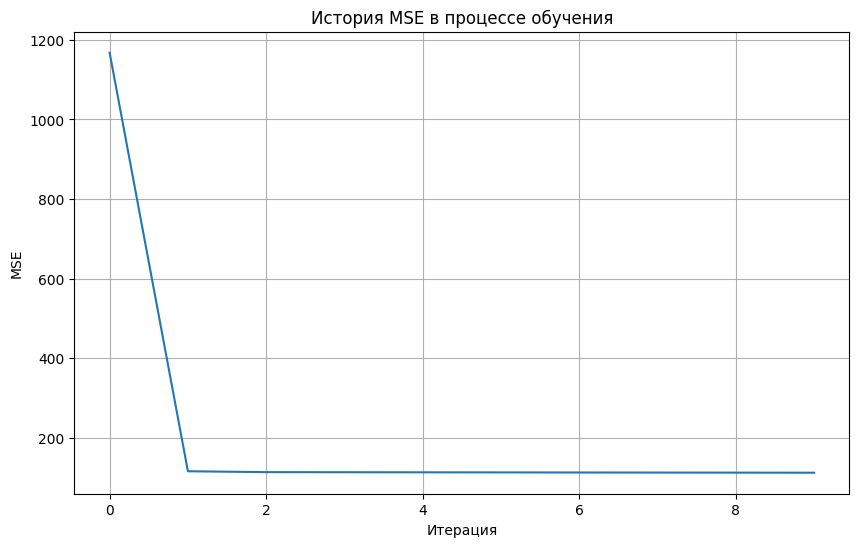

In [61]:
# Обучите оба регрессора на загруженных данных
pseudo_model = PseudoInvRegressor()
pseudo_model.fit(X_train, y_train)
pseudo_preds = pseudo_model.predict(X_test)
pseudo_mse = np.mean((pseudo_preds - y_test)**2)
print(f"MSE для PseudoInvRegressor: {pseudo_mse:.4f}")
print("Веса:", pseudo_model.weights_)


grad_model = GradRegressor(
    # Для второго регрессора придется поэкспериментировать 
    learning_rate=0.0001, # со скоростью и  
    n_iterations=10) # продолжительностью обучения
grad_model.fit(X_train, y_train)
grad_preds = grad_model.predict(X_test)
grad_mse = np.mean((grad_preds - y_test)**2)
print(f"MSE для GradRegressor: {pseudo_mse:.4f}")
print("Веса:", pseudo_model.weights_)

# Постройте график ошибок. 
plt.figure(figsize=(10, 6))
plt.plot(grad_model.loss_history_)
plt.title("История MSE в процессе обучения")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

**3.** Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров. Для этого воспользуйтесь скейлерами из sklearn. Метод fit_transform позволяет сразу и настроить параметры скейлера и выполнить масштабирование. **Внимание!** Обучать (fit) скейлер нужно только на тренировочных данных. А потом с полученными на них параметрами применять его к тестовым. **Еще внимание!** Если в вашей матрице $X$ был столбик для свободного члена, после масштабирования он станет нулевым. Это не то, чего нам бы хотелось, это надо пофиксить

Итак, что изменилось?

Контрольные вопросы: зачем масштабировать данные? Когда это обязательно, когда не очень? Надо ли масштабировать $y$? Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?

MSE для псевдообратного регрессора (scaled): 4.0826
0: MSE = 3278.3875580185017
5: MSE = 2679.9191614722768
10: MSE = 2190.8436766768873
15: MSE = 1791.1647315885195
20: MSE = 1464.5412881411692
25: MSE = 1197.6194267920876
30: MSE = 979.4862883432176
35: MSE = 801.2238406429151
40: MSE = 655.5442206297762
45: MSE = 536.4917385790774
50: MSE = 439.19935782935937
55: MSE = 359.6896912260266
60: MSE = 294.7123761537221
65: MSE = 241.61117781056947
70: MSE = 198.21538616010804
75: MSE = 162.75106550959543
80: MSE = 133.7685275429695
85: MSE = 110.08306209016432
90: MSE = 90.72650207748299
95: MSE = 74.90764215087654
100: MSE = 61.97989251577086
105: MSE = 51.41484540105018
110: MSE = 42.78067333132465
115: MSE = 35.724475968809855
120: MSE = 29.95785374436945
125: MSE = 25.245118439616487
130: MSE = 21.393658704343434
135: MSE = 18.246066605378665
140: MSE = 15.67370330756941
145: MSE = 13.57144082952472
150: MSE = 11.853364902268957
155: MSE = 10.44926325441293
160: MSE = 9.3017557597235

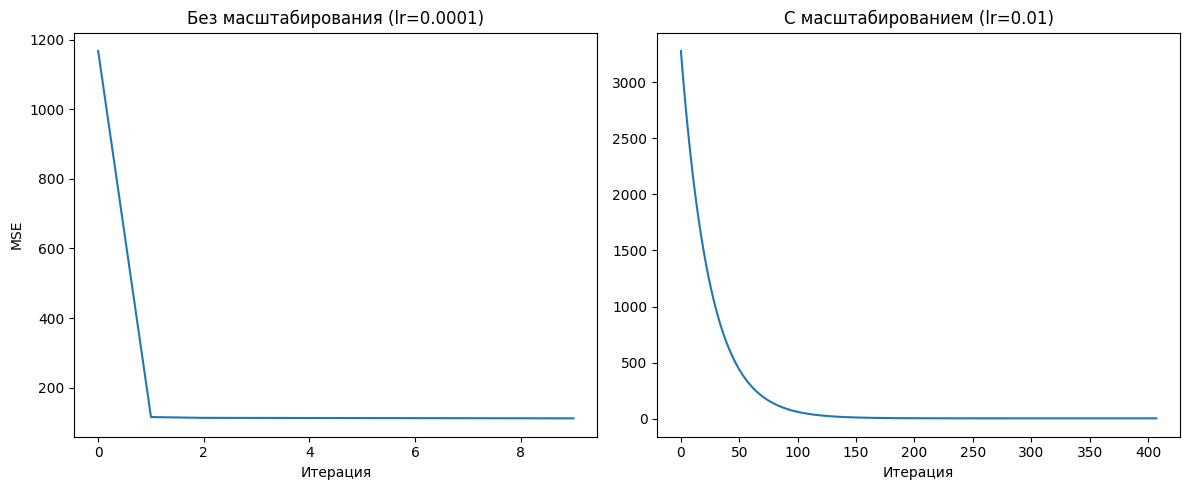

In [62]:
# Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров.

# Для этого воспользуйтесь скейлерами из sklearn.
# на ваш выбор
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()

# Метод fit_transform позволяет сразу 
# и настроить параметры скейлера и выполнить масштабирование
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pseudo_model_scaled = PseudoInvRegressor()
pseudo_model_scaled.fit(X_train_scaled, y_train)
pseudo_preds_scaled = pseudo_model_scaled.predict(X_test_scaled)
pseudo_mse_scaled = np.mean((pseudo_preds_scaled - y_test)**2)
print(f"MSE для псевдообратного регрессора (scaled): {pseudo_mse_scaled:.4f}")

grad_model_scaled = GradRegressor(
    learning_rate=0.01, 
    n_iterations=1000)
grad_model_scaled.fit(X_train_scaled, y_train)
grad_preds_scaled = grad_model_scaled.predict(X_test_scaled)
grad_mse_scaled = np.mean((grad_preds_scaled - y_test)**2)
print(f"MSE для градиентного регрессора (scaled): {grad_mse_scaled:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(grad_model.loss_history_)
plt.title("Без масштабирования (lr=0.0001)")
plt.xlabel("Итерация"); plt.ylabel("MSE")

plt.subplot(1, 2, 2)
plt.plot(grad_model_scaled.loss_history_)
plt.title("С масштабированием (lr=0.01)")
plt.xlabel("Итерация")
plt.tight_layout()
plt.show()



= Итак, что изменилось?
из явного 
- изменился график, он стал гладким.
- можно увеличить шаг lt. в данном прогоне он у меня в 100 раз больше (0.01), чем я использовал в Без масштабирования (с таким шагом для данных Без масштабирования MSE уходили в бесконечность)
- Градиентом получилось найти даже более оптимальное решение. более точное, чем аналитическим решением (по всей видимости это связано с вычислениями чисел с плавающей точкой)

Контрольные вопросы: 

= Зачем масштабировать данные? Когда это обязательно, когда не очень?
- Масштабирование данных, это процесс приведения признаков к "подобному" виду. к примеру -- два параметра, один от 1 до 10, другой от 1 до 100. Изменение на 1 одного и другого -- это 10% и 1% соответственно. то есть, один из параметров может считаться более "важным" (разные веса признаков). и чтобы этого избежать, занимаются масштабированием данных. 
- это особенно может быть проблемой для тех, кто использует работу с градиентами -- шаги вдоль признаков могут быть большими/маленькими из-за проблемы с их масштабом. и регуляризацией тоже.
- если же такой нужды в масштабе нет (например, категории тд), то и масштабировать не нужно

= Надо ли масштабировать $y$? 
- технически нет, ведь: если посмотреть на уравнение $y = X*w + w_0$, то если промасштабировать $X$, то измениться и матрица весов $w$ (модель найдет его другой), и в результате будет все равно получиться тот же $y$.

= Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?
- ассимтотическая сложность вычисления псевдообратной O(количество признаков^3) и O(количество признаков^2) памяти. А градиентные методы просят перемножение матрицы и вектора, что занимает O(n) / O(n log n)
- когда данные "доходят", то придется пересчитывать псевдообратную (либо каждый раз, либо "реже"). а градиентный способ позволяет обновлять постепенно
- из-за плохой обусловленности вычисление псевдообратной может быть неустойчивым 

**4.** Добавим возможность l1 и l2 регуляризации. Это означает, что функция потерь примет вид

$$\frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$

где $\lambda_1$, $\lambda_2$ отвечают за выраженность l1 и l2 регуляризаций и могут их выключить, будучи равными 0.

Здесь мы сталкиваемся с проблемой в случае псевдообратного решения - из-за того, что модуль недифференцируем в 0, мы, вообще-то, не можем получить одну конечную формулу для решения. Но для l2 все в порядке. 

Итак, для **псевдообратного регрессора** выведите новую формулу с учетом l2-регуляризации. Выводится она из тех соображений, что искомое $w$ - это точка, где достигается экстремум функции потерь, т.е. равна 0 ее производная. Добавьте в класс этого регрессора l2-регуляризацию.

Для **градиентного регрессора** добавьте обе регуляризации (производной модуля будем считать $sgn$).

```
Итак, для **псевдообратного регрессора** выведите новую формулу с учетом l2-регуляризации.
```
то есть, мы берем исходную формулу
$$Loss(w) = \frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$
и "выключаем" l1
$$Loss(w) = \frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_2\sum_{j=1}^m w_j^2,$$
в матричном виде
$$ Loss(w) = (Xw - y)^T(Xw - y) + \lambda w^Tw $$

```
Выводится она из тех соображений, что искомое $w$ - это точка, где достигается экстремум функции потерь, т.е. равна 0 ее производная.
```
$$ \frac{\partial Loss}{\partial w} = \frac{\partial}{\partial w} \left( (Xw - y)^T(Xw - y) \right) + \frac{\partial}{\partial w} \left( \lambda w^Tw \right) = 0 $$
$$ 2X^T(Xw - y) + 2\lambda w = 0 $$
$$ X^T(Xw - y) + \lambda w = 0 $$
$$ X^TXw - X^Ty + \lambda w = 0 $$
$$ X^TXw + \lambda w = X^Ty $$
$$ (X^TX + \lambda I)w = X^Ty $$

Итого
$$ w = (X^TX + \lambda I)^{-1} X^Ty $$

```
Добавьте в класс этого регрессора l2-регуляризацию.
```

In [63]:
class PseudoInvRegressorL2(BaseEstimator, RegressorMixin):
    def __init__(self, l2_lambda):
        self.l2_lambda = l2_lambda
        self.weights_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        
        I = np.eye(n_features)
        
        I[0, 0] = 0 # w0 не "штрафуется"
        term1 = np.linalg.inv(X_with_bias.T @ X_with_bias + self.l2_lambda * I)
        term2 = X_with_bias.T @ y
        self.weights_ = term1 @ term2
        
        return self
    
    def predict(self, X): 
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_

```
Для **градиентного регрессора** добавьте обе регуляризации (производной модуля будем считать $sgn$).
```
исходная функция
$$Loss(w) = \frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$

для нее
$$\nabla Loss = \frac{2}{N} X^T(Xw - y) + \lambda_1 \cdot \text{sgn}(w) + 2\lambda_2 w$$


In [64]:
class GradRegressorWithRegularization(BaseEstimator, RegressorMixin): 
    def __init__(self, learning_rate=0.001, n_iterations=1000, l1_lambda=0.0, l2_lambda=0.0, tolerance=1e-5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations # max количество итераций
        self.tolerance = tolerance
        self.weights_ = None
        self.loss_history_ = []
        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda
        self.n_iter_ = None
        
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        self.weights_ = np.random.randn(n_features)
        
        prev_loss = float('inf')
        
        for i in range(self.n_iterations):
            predictions = X_with_bias @ self.weights_
            
            mse_loss = np.mean((predictions - y)**2)
            l1_loss = self.l1_lambda * np.sum(np.abs(self.weights_[1:]))
            l2_loss = self.l2_lambda * np.sum(self.weights_[1:]**2)
            loss = mse_loss + l1_loss + l2_loss
            
            self.loss_history_.append(loss)
            
            if abs(prev_loss - loss) < self.tolerance:
                print(f"Остановка на итерации {i+1}")
                break
            prev_loss = loss
            
            # $$\nabla Loss = \frac{2}{N} X^T(Xw - y) + \lambda_1 \cdot \text{sgn}(w) + 2\lambda_2 w$$
            # $$\nabla \frac{2}{N} X^T(Xw - y) $$
            mse_gradient = (2/n_samples) * X_with_bias.T @ (predictions - y)
            
            weights_for_grad = self.weights_.copy()
            weights_for_grad[0] = 0
        
            # $$\lambda_1 \cdot \text{sgn}(w)$$
            l1_gradient = self.l1_lambda * np.sign(weights_for_grad)
            # $$2\lambda_2 w$$
            l2_gradient = self.l2_lambda * weights_for_grad
            
            gradient = mse_gradient + l1_gradient + l2_gradient
            
            self.weights_ = self.weights_ - self.learning_rate * gradient
            print(f"Итерация {i}: Loss = {loss}")
        self.n_iter_ = i + 1
            
        return self
    
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.weights_                

**5.** Обучите ваши регрессоры с этими новыми настройками. Рассмотрите 3 случая: 
- псевдообратные регрессор с l2
- градиентный регрессор с l1
- градиентный регрессор с l2

Подберите какие-то лямбды, дающие адекватный результат. Потом загрузите регрессоры из sklearn и обучите их с теми же (насколько это возможно) настройками. Сравните полученные веса и ошибку на тренировочном и тестовых множествах (выведите их куда-нибудь в одно место, вместе с параметрами, чтоб красиво. Можно, например, собрать из них маленький датафрейм)

Когда пойдете читать справку для Lasso и Ridge, обратите внимание на описываемые способы решения: в Ridge(l2) есть несколько опций, в том числе детерминированных; в Lasso(l1) используется координатный спуск.

Контрольный вопрос: почему про L1 говорят, что он отбирает признаки, а L2 - нет?

In [65]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, Ridge

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Подберите какие-то лямбды, дающие адекватный результат.
L2_LAMBDA = 0.01
L1_LAMBDA = 0.1

results = []

# псевдообратные регрессор с l2
my_pseudo = PseudoInvRegressorL2(l2_lambda=L2_LAMBDA)
my_pseudo.fit(X_train_scaled, y_train)
train_predicitons = my_pseudo.predict(X_train_scaled)
test_predictions = my_pseudo.predict(X_test_scaled)
results.append({
    "модель": "Моя PseudoInv L2",
    "Lambda": L2_LAMBDA,
    "итерации": "0",
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": my_pseudo.weights_
})

# градиентный регрессор с l1
my_grad_l1 = GradRegressorWithRegularization(
    learning_rate=0.01, 
    n_iterations=1000, 
    l1_lambda=L1_LAMBDA)
my_grad_l1.fit(X_train_scaled, y_train)
train_predicitons = my_grad_l1.predict(X_train_scaled)
test_predictions = my_grad_l1.predict(X_test_scaled)

results.append({
    "модель": "Моя Grad с L1",
    "Lambda": L1_LAMBDA,
    "итерации": my_grad_l1.n_iter_,
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": my_grad_l1.weights_
})

# градиентный регрессор с l2
my_grad_l2 = GradRegressorWithRegularization(
    learning_rate=0.01, 
    n_iterations=1000, 
    l2_lambda=L2_LAMBDA)
my_grad_l2.fit(X_train_scaled, y_train)
train_predicitons = my_grad_l2.predict(X_train_scaled)
test_predictions = my_grad_l2.predict(X_test_scaled)

results.append({
    "модель": "Моя Grad с L2",
    "Lambda": L2_LAMBDA,
    "итерации": my_grad_l2.n_iter_,
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": my_grad_l2.weights_
})

# Потом загрузите регрессоры из sklearn 
# и обучите их с теми же (насколько это возможно) настройками.

# Sklearn
sklearn_ridge = Ridge(alpha=L2_LAMBDA)
sklearn_ridge.fit(X_train_scaled, y_train)
train_predicitons = sklearn_ridge.predict(X_train_scaled)
test_predictions = sklearn_ridge.predict(X_test_scaled)

sklearn_ridge_weights = np.insert(sklearn_ridge.coef_, 0, sklearn_ridge.intercept_)
results.append({
    "модель": "Sklearn Ridge",
    "Lambda": L2_LAMBDA,
    "итерации": "0",
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": sklearn_ridge_weights
})

sklearn_lasso = Lasso(alpha=L1_LAMBDA)
sklearn_lasso.fit(X_train_scaled, y_train)
train_predicitons = sklearn_lasso.predict(X_train_scaled)
test_predictions = sklearn_lasso.predict(X_test_scaled)

sklearn_lasso_weights = np.insert(sklearn_lasso.coef_, 0, sklearn_lasso.intercept_)
results.append({
    "модель": "Sklearn Lasso",
    "Lambda": L1_LAMBDA,
    "итерации": sklearn_lasso.n_iter_,
    "тренировочная MSE": mean_squared_error(y_train, train_predicitons),
    "тест MSE": mean_squared_error(y_test, test_predictions),
    "веса": sklearn_lasso_weights
})

# Сравните полученные веса и ошибку на тренировочном 
# и тестовых множествах (выведите их куда-нибудь в одно место, 
# вместе с параметрами, чтоб красиво.
# Можно, например, собрать из них маленький датафрейм)
df_results = pd.DataFrame(results)
df_results['отформатированные веса'] = df_results['веса'].apply(lambda w: np.round(w, 2))
display(df_results[['модель', 'Lambda', 'итерации', 'тренировочная MSE', 'тест MSE', 'отформатированные веса']])

Итерация 0: Loss = 3391.1847217288
Итерация 1: Loss = 3257.260140403095
Итерация 2: Loss = 3128.6350027742146
Итерация 3: Loss = 3005.099601076856
Итерация 4: Loss = 2886.4525262966813
Итерация 5: Loss = 2772.500339754022
Итерация 6: Loss = 2663.0572576848003
Итерация 7: Loss = 2557.9448483042697
Итерация 8: Loss = 2456.9917408595616
Итерация 9: Loss = 2360.0333461965447
Итерация 10: Loss = 2266.9115883853146
Итерация 11: Loss = 2177.474646966651
Итерация 12: Loss = 2091.5767093990976
Итерация 13: Loss = 2009.0777333029637
Итерация 14: Loss = 1929.843218113529
Итерация 15: Loss = 1853.7439857710553
Итерация 16: Loss = 1780.6559700899809
Итерация 17: Loss = 1710.4600144637923
Итерация 18: Loss = 1643.0416775756967
Итерация 19: Loss = 1578.29104679824
Итерация 20: Loss = 1516.1033182279155
Итерация 21: Loss = 1456.3821134497693
Итерация 22: Loss = 1399.0240289348424
Итерация 23: Loss = 1343.9355547768564
Итерация 24: Loss = 1291.0268814270871
Итерация 25: Loss = 1240.2117532597388
Итерац

,модель,Lambda,итерации,тренировочная MSE,тест MSE,отформатированные веса
0,Моя PseudoInv L2,0.01,0,4.169736,4.082634,"[55.31, 7.4, 17.64, 0.3, 0.81, 0.55]"
1,Моя Grad с L1,0.10,409,4.183092,4.115610,"[55.3, 7.35, 17.58, 0.25, 0.76, 0.5]"
2,Моя Grad с L2,0.01,365,4.182818,4.115837,"[55.28, 7.36, 17.54, 0.3, 0.8, 0.55]"
3,Sklearn Ridge,0.01,0,4.169736,4.082634,"[55.31, 7.4, 17.64, 0.3, 0.81, 0.55]"
4,Sklearn Lasso,0.10,3,4.219624,4.175297,"[55.31, 7.3, 17.54, 0.2, 0.71, 0.45]"


```
Когда пойдете читать справку для Lasso и Ridge, обратите внимание на описываемые способы решения: в Ridge(l2) есть несколько опций, в том числе детерминированных; в Lasso(l1) используется координатный спуск.
```

```
Контрольный вопрос: почему про L1 говорят, что он отбирает признаки, а L2 - нет?
```
"отобрать" это значит, что признак зануляется 
то есть L1 может занулить признак, а L2 не занулит его

### Почему?
градиент для L1 -- он постоянный, а градиент для L2 -- он пропорционален $$w$$
то есть 
$$\nabla Loss(w) = MSE(w) + L1(w) + L2(w)$$
где
$$\nabla MSE(w) = \frac{2}{N} X^T(Xw - y)$$
$$\nabla L1(w) = \lambda_1 \cdot \text{sgn}(w)$$
$$\nabla L2(w) = 2\lambda_2 w$$
L2 стремит w_i к 0, но не делает его нулевым. а L1 он стабильно уменьшает вес И если тот стал 0, то больше с ним ничего не делает (sign(0) = 0)

**6.** Почитайте справку для класса SGDRegressor и сообразите, как сделать так, чтобы он оптимизировал MAE, а не MSE. Обучите два регрессора - один с абсолютной ошибкой, другой с квадратичной. Сравните веса, значения обеих ошибок на тренировочном и тестовом наборах

MSE (Mean Squared Error) (чем больше ошибка, тем сильнее она наказывается): $$ \frac{1}{N}\sum (y_i - \hat{y}_i)^2 $$
MAE (Mean Absolute Error)(ошибки наказываются пропорционально): $$ \frac{1}{N}\sum |y_i - \hat{y}_i| $$

# Что я выбрал для MAE и MSE
сделал я вот что
```python
SGDRegressor(loss='squared_error', random_state=42, max_iter=1000, tol=1e-3)
SGDRegressor(loss='epsilon_insensitive', random_state=42, max_iter=1000, epsilon=0)
```
формулы из документации
[тут](https://scikit-learn.org/stable/modules/sgd.html#sgd-mathematical-formulation)
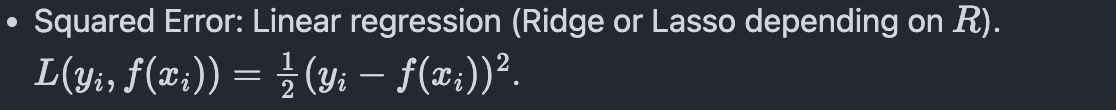
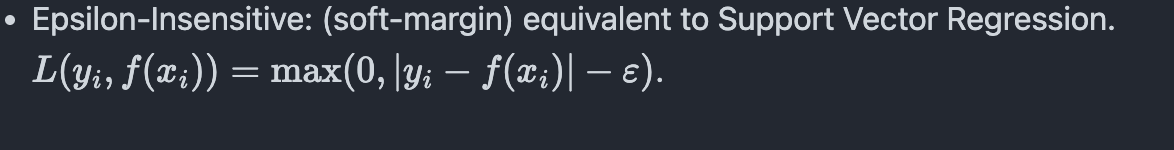


In [66]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

# MSE
sgd_mse = SGDRegressor(loss='squared_error', random_state=42, max_iter=1000, tol=1e-3)
sgd_mse.fit(X_train_scaled, y_train)

# Почитайте справку для класса SGDRegressor и сообразите, как сделать так, чтобы он оптимизировал MAE, а не MSE. 
# MAE
sgd_mae = SGDRegressor(loss='epsilon_insensitive', random_state=42, max_iter=1000, epsilon=0)
sgd_mae.fit(X_train_scaled, y_train)

results_mae_vs_mse = []

# MSE
train_preds_mse = sgd_mse.predict(X_train_scaled)
test_preds_mse = sgd_mse.predict(X_test_scaled)
weights_mse = np.insert(sgd_mse.coef_, 0, sgd_mse.intercept_)
results_mae_vs_mse.append({
    "модель": "MSE",
    "тренировочная MSE": mean_squared_error(y_train, train_preds_mse),
    "тест MSE": mean_squared_error(y_test, test_preds_mse),
    "тренировочная MAE": mean_absolute_error(y_train, train_preds_mse),
    "тест MAE": mean_absolute_error(y_test, test_preds_mse),
    "веса": np.round(weights_mse, 2)
})

# MAE
train_preds_mae = sgd_mae.predict(X_train_scaled)
test_preds_mae = sgd_mae.predict(X_test_scaled)
weights_mae = np.insert(sgd_mae.coef_, 0, sgd_mae.intercept_)
results_mae_vs_mse.append({
    "модель": "MAE",
    "тренировочная MSE": mean_squared_error(y_train, train_preds_mae),
    "тест MSE": mean_squared_error(y_test, test_preds_mae),
    "тренировочная MAE": mean_absolute_error(y_train, train_preds_mae),
    "тест MAE": mean_absolute_error(y_test, test_preds_mae),
    "веса": np.round(weights_mae, 2)
})

df_comparison = pd.DataFrame(results_mae_vs_mse)
display(df_comparison)

,модель,тренировочная MSE,тест MSE,тренировочная MAE,тест MAE,веса
0,MSE,4.172648,4.085784,1.620282,1.611472,"[55.32, 7.35, 17.64, 0.3, 0.81, 0.55]"
1,MAE,4.172280,4.088634,1.618943,1.612473,"[55.28, 7.41, 17.61, 0.32, 0.81, 0.53]"


что мы можем видеть 
- результаты очень похожи
- каждая модель показывает себя лучше в своей метрике (MSE минимизировала MSE, а MAE MAE)
- и отсюда можно сделать вывод, что минимумы функций могут быть где-то рядом. и это вероятно связанно с искуственностью наших данных 





**7.** В датасете со студентами у нас был нормально распределенный таргет. Вообще-то это как бы не обязательно (нормальному распределению должны следовать ошибки; да и это тоже необязательно - смотря какие выводы вы хотите потом сделать о модели), но в некоторых туториалах можно встретить и такое требование. А еще в некоторых - требование нормального распределения фичей. Математического пояснения этому обычно не дается, а говорится что-то вроде "модель эффективнее обучается на нормально распределенных данных". 

Загрузите датасет с ценами медстраховки (https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset ). Масштабируйте данные, предобработайте категориальные признаки. Попробуйте скорректировать а) распределение целевой переменной б) распределения не бинарных фичей до нормального. На этих данных обучите модели настолько хорошо, насколько сможете, и сравните их качество с моделями без подобных преобразований. Сравнивать будем по MSE на тесте (20%), при этом если вы преобразовали целевую переменную, не забудьте преобразовать ее обратно прежде чем вычислять эту MSE для сравнения

**Внимание!** Корректировка распределения проводится по тренировочным данным. По ним вы определяете некое преобразование, которое потом будет применяться на тест

# Анализируем данные

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max     

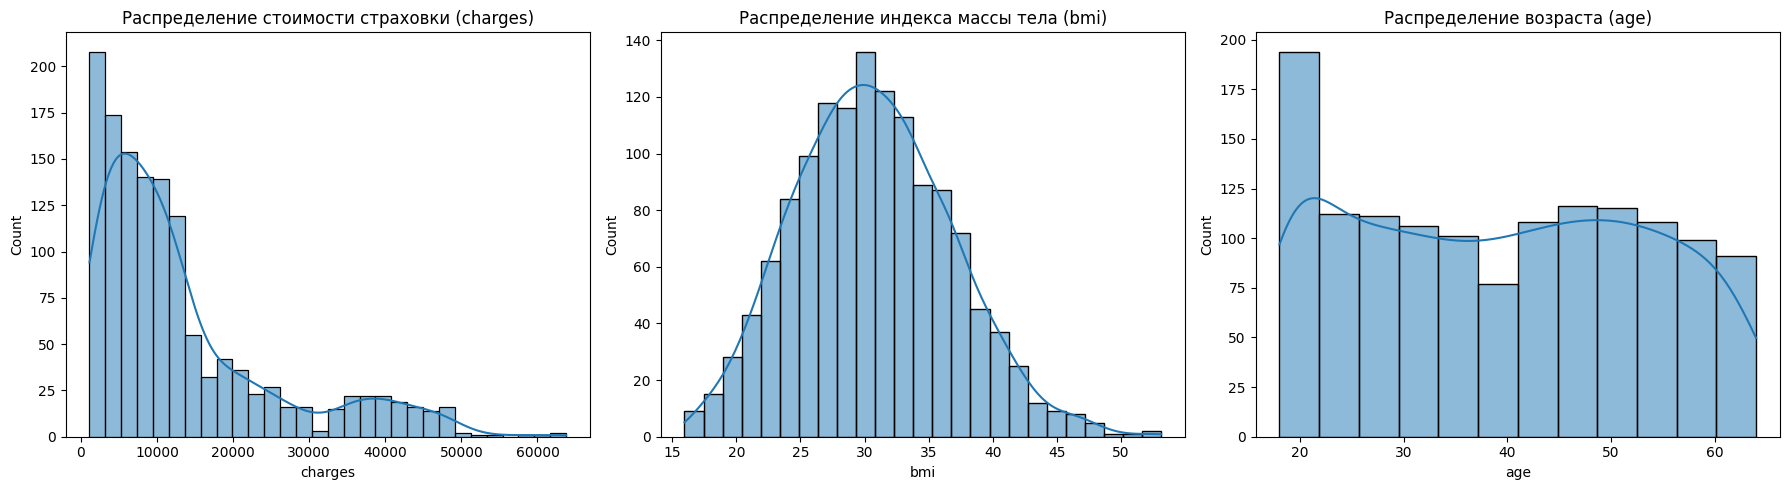

In [67]:
# загружаем
df_insurance = pd.read_csv('insurance.csv')
df_insurance.info()
print(df_insurance.describe())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_insurance['charges'], kde=True)
plt.title('Распределение стоимости страховки (charges)')

plt.subplot(1, 3, 2)
sns.histplot(df_insurance['bmi'], kde=True)
plt.title('Распределение индекса массы тела (bmi)')

plt.subplot(1, 3, 3)
sns.histplot(df_insurance['age'], kde=True)
plt.title('Распределение возраста (age)')

plt.tight_layout()
plt.show()


In [68]:
# полностью сырые данные
df_baseline = df_insurance.copy()

X_baseline = df_insurance[['age', 'bmi', 'children']]
y_baseline = df_insurance['charges']

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42
)

display(X_baseline.head())
display(y_baseline.head())


,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [69]:
# обработка бинарных признаков и категорий
df_processed = df_insurance.copy()

df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})

df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True, dtype=int)

X_processed = df_processed.drop('charges', axis=1)
y_processed = df_processed['charges']

X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)

display(X_processed.head())
display(y_processed.head())

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [70]:
# отмасштабированные
from sklearn.preprocessing import StandardScaler

# будем масштабировать
numerical_features = ['age', 'bmi', 'children']

# Создаем и обучаем скейлер ТОЛЬКО на тренировочных данных
scaler = StandardScaler()
X_train_scaled = X_train_processed.copy()
X_test_scaled = X_test_processed.copy()

# Применяем масштабирование
X_train_scaled[numerical_features] = scaler.fit_transform(X_train_processed[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_processed[numerical_features])

y_train_scaled = y_train_processed
y_test_scaled = y_test_processed

print("без масштабирования")
display(X_processed.head())
print("с масштабированием")
display(X_train_scaled.head())

без масштабирования


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


с масштабированием


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,0.472227,0,-1.756525,0.734336,0,1,0,0
1285,0.543313,0,-1.033082,-0.911192,0,0,0,0
1142,0.898745,0,-0.943687,-0.911192,0,0,1,0
969,-0.025379,0,0.622393,3.202629,0,0,1,0
486,1.040918,0,-1.504893,1.557100,0,1,0,0


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,0.512462,0,-1.898858,0.734336,0,1,0,0
1285,0.578718,0,-1.040246,-0.911192,0,0,0,0
1142,0.903422,0,-0.940060,-0.911192,0,0,1,0
969,0.034790,0,0.654794,3.202629,0,0,1,0
486,1.030443,0,-1.589812,1.557100,0,1,0,0


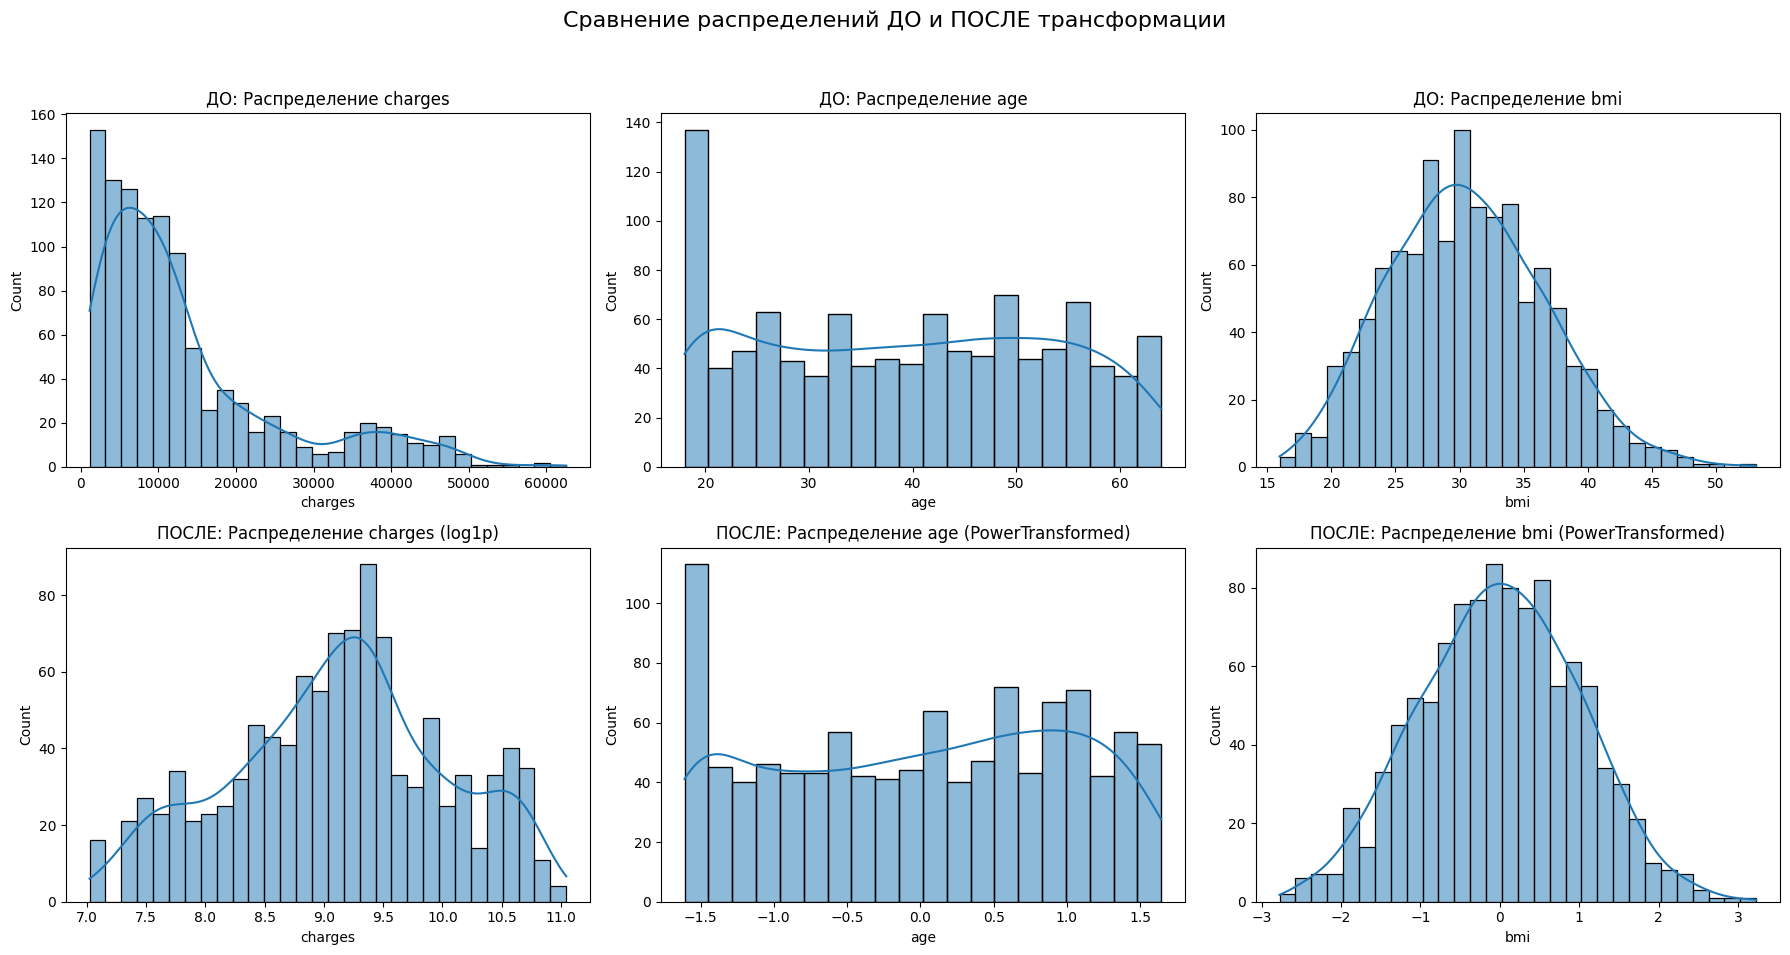

In [76]:
# "выпрямляем" данные
from sklearn.preprocessing import PowerTransformer
from scipy import stats # stats.boxcox(y) и PowerTransformer(method='box-cox')

power_features = ['age', 'bmi']

power_transformer = PowerTransformer()
X_train_transformed = X_train_processed.copy()
X_test_transformed = X_test_processed.copy()

# применяем
X_train_transformed[power_features] = power_transformer.fit_transform(X_train_processed[power_features])
X_test_transformed[power_features] = power_transformer.transform(X_test_processed[power_features])

# приводим 'children' к нужному масштабу
scaler_children = StandardScaler()
X_train_transformed[['children']] = scaler_children.fit_transform(X_train_processed[['children']])
X_test_transformed[['children']] = scaler_children.transform(X_test_processed[['children']])

y_train_transformed_log = np.log1p(y_train_processed) # логарифмируем
y_test_transformed = y_test_processed # тестовый y будет в исходном виде

display(X_train_transformed.head())

plt.figure(figsize=(18, 10))
plt.suptitle('Сравнение распределений ДО и ПОСЛЕ трансформации', fontsize=16)

# --- Распределения ДО ---
plt.subplot(2, 3, 1)
sns.histplot(y_train_processed, kde=True, bins=30)
plt.title('ДО: Распределение charges')

plt.subplot(2, 3, 2)
sns.histplot(X_train_processed['age'], kde=True, bins=20)
plt.title('ДО: Распределение age')

plt.subplot(2, 3, 3)
sns.histplot(X_train_processed['bmi'], kde=True, bins=30)
plt.title('ДО: Распределение bmi')

# --- Распределения ПОСЛЕ ---
plt.subplot(2, 3, 4)
sns.histplot(y_train_transformed_log, kde=True, bins=30)
plt.title('ПОСЛЕ: Распределение charges (log1p)')

plt.subplot(2, 3, 5)
sns.histplot(X_train_transformed['age'], kde=True, bins=20)
plt.title('ПОСЛЕ: Распределение age (PowerTransformed)')

plt.subplot(2, 3, 6)
sns.histplot(X_train_transformed['bmi'], kde=True, bins=30)
plt.title('ПОСЛЕ: Распределение bmi (PowerTransformed)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# Обучаем

In [80]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import pandas as pd

# список для хранения результатов
final_results = []

print("--- Baseline ---")
model_baseline = Ridge(alpha=1.0)
model_baseline.fit(X_train_baseline, y_train_baseline)
y_pred_baseline = model_baseline.predict(X_test_baseline)
mse_baseline = mean_squared_error(y_test_baseline, y_pred_baseline)

final_results.append({
    "Модель": "1. Baseline",
    "Предобработка": "Нет",
    "Тестовая MSE": mse_baseline
})
print(f"MSE = {mse_baseline:.2f}")


print("\n--- Processed ---")
model_processed = Ridge(alpha=1.0)
model_processed.fit(X_train_processed, y_train_processed)
y_pred_processed = model_processed.predict(X_test_processed)
mse_processed = mean_squared_error(y_test_processed, y_pred_processed)

final_results.append({
    "Модель": "2. Processed",
    "Предобработка": "One-Hot Encoding",
    "Тестовая MSE": mse_processed
})
print(f"MSE = {mse_processed:.2f}")


print("\n--- Scaled ---")
model_scaled = Ridge(alpha=1.0)
model_scaled.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = model_scaled.predict(X_test_scaled)
mse_scaled = mean_squared_error(y_test_scaled, y_pred_scaled)

final_results.append({
    "Модель": "3. Scaled",
    "Предобработка": "One-Hot + StandardScaler",
    "Тестовая MSE": mse_scaled
})
print(f"MSE = {mse_scaled:.2f}")


print("\n--- Transformed ---")
model_transformed = Ridge(alpha=1.0)
model_transformed.fit(X_train_transformed, y_train_transformed_log) # обучаем на трансформированных X и логарифмированном y
y_pred_log = model_transformed.predict(X_test_transformed) # делаем предсказания (они будут в лог-масштабе)
y_pred_transformed = np.expm1(y_pred_log) # преобразуем предсказания обратно в исходный масштаб
mse_transformed = mean_squared_error(y_test_transformed, y_pred_transformed) # MSE на исходных данных

final_results.append({
    "Модель": "4. Transformed",
    "Предобработка": "One-Hot + PowerTransformer + Log(y)",
    "Тестовая MSE": mse_transformed
})
print(f"MSE = {mse_transformed:.2f}")

--- Baseline ---
MSE = 131201249.69

--- Processed ---
MSE = 33645037.09

--- Scaled ---
MSE = 33645393.49

--- Transformed ---
MSE = 57058410.07


# Таблица

In [79]:
df_final_results = pd.DataFrame(final_results)
df_final_results['Тестовый sqrt(MSE) ($)'] = np.sqrt(df_final_results['Тестовая MSE'])

print("\n\n--- ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ ---")
display(df_final_results)



--- ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ ---


,Модель,Предобработка,Тестовая MSE,Тестовый sqrt(MSE) ($)
0,1. Baseline,Нет,1.312012e+08,11454.311402
1,2. Processed,One-Hot Encoding,3.364504e+07,5800.434216
2,3. Scaled,One-Hot + StandardScaler,3.364539e+07,5800.464938
3,4. Transformed,One-Hot + PowerTransformer + Log(y),5.705841e+07,7553.701746


# Анализ результатов

## Что видим
четвертая модель, которая у нас "самая лудшая", ухудшила результат

## С чем это связано
связанно это с тем, Что модель оптимизировала и Как мы оценивали результат. \
4-ая модель обучаласьь на логарифмических значениях, где ошибка в 2 раза "наказывается" сильнее (например 1000 и 2000), чем 10% в логарифмической (40000 и 44000) (в этом случае абсолютная разница больше) \
исходная наша оценка MSE чувствительная к абсолютным ошибкам (ибо возводит их в квадрат). тем самым 4000$ внесут куда больше вклад, чем 1000$ \
то есть, логарифмическое расперделение минимизирует относителньные ошибки, хотя для низкой MSE нужно минимизировать абсолютные ошибки

что я имеею в виду \
Без log -- модель уменьшает абсолютные ошибки, то есть жестка штрафует за На сколько больше
$$L(no-log) = (y_p - y)^2$$
*   **Маленькие значения:**
    *   `y_true = 1000`
    *   `y_pred = 2000`
    *   Абсолютная ошибка: `2000 - 1000 = 1000$`
    *   Вклад в ошибку: `(1000)² = 1,000,000`

*   **Большие значения:**
    *   `y_true = 40000`
    *   `y_pred = 44000`
    *   Абсолютная ошибка: `44000 - 40000 = 4000$`
    *   Вклад в ошибку: `(4000)² = 16,000,000`

С лог -- решает имнно Во сколько отличаются 
$$L(log) = (log(y_p) - log(y))^2$$
*   **Случай А (маленькие значения):**
    *   `log(y_true) = ln(1000) ≈ 6.907`
    *   `log(y_pred) = ln(2000) ≈ 7.600`
    *   log ошибка: `7.600 - 6.907 = 0.693`
    *   Вклад в ошибку : `(0.693)² ≈ 0.48`

*   **Случай Б (большие значения):**
    *   `log(y_true) = ln(40000) ≈ 10.596`
    *   `log(y_pred) = ln(44000) ≈ 10.691`
    *   log ошибка: `10.691 - 10.596 = 0.095`
    *   Вклад в ошибку: `(0.095)² ≈ 0.009`




**8.** Добавим в наши данные немного мусора. Сделайте колонку с id пациента (числа от 0 до ...) и его любимым цветом (случайный цвет, заданный тремя параметрами RGB, распределение случайных величин - на ваше усмотрение). Проведите предобработку данных, которую посчитаете нужной, только не выбрасывайте наши мусорные колонки. Чтобы поменьше заниматься подбором параметров, обучим следующием модели:

- псевдообратный регрессор
- псевдообратный регрессор с L2 регуляризацией
- псевдообратный регрессор, но мы выбросили id
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили id
- псевдообратный регрессов, но мы выбросили и id, и цвета
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили и id, и цвета

Вычислите для каждой модели $R^2$ и скорректированный $R^2$ на тестовом и на тренировочном множествах, сведите в табличку. Какие выводы можно сделать из увиденного? 

In [84]:
df_garbage = df_processed.copy()

# 1. ID
num_patients = len(df_garbage)
df_garbage['patient_id'] = np.arange(num_patients)

# 2. случайный цвет (RGB)
np.random.seed(42)
df_garbage['color_r'] = np.random.randint(0, 256, size=num_patients)
df_garbage['color_g'] = np.random.randint(0, 256, size=num_patients)
df_garbage['color_b'] = np.random.randint(0, 256, size=num_patients)

cols_order = ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 
              'region_southeast', 'region_southwest', 'patient_id', 
              'color_r', 'color_g', 'color_b', 'charges']
df_garbage = df_garbage[cols_order]

display(df_garbage.head())

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,patient_id,color_r,color_g,color_b,charges
0,19,0,27.900,0,1,0,0,1,0,102,61,92,16884.92400
1,18,1,33.770,1,0,0,1,0,1,179,93,181,1725.55230
2,28,1,33.000,3,0,0,1,0,2,92,94,190,4449.46200
3,33,1,22.705,0,0,1,0,0,3,14,151,206,21984.47061
4,32,1,28.880,0,0,1,0,0,4,106,54,96,3866.85520


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# наборы признаков для разных моделей
X_all = df_garbage.drop('charges', axis=1)
y = df_garbage['charges']

# разделяем данные на обучающую и тестовую выборки
X_train_full, X_test_full, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# масштабируем ВСЕ числовые признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

# Преобразуем обратно в DataFrame для удобства удаления колонок
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_all.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_all.columns)

# --- датасеты для разных моделей ---
# 1. с ID, с Цветом
X_train_all = X_train_scaled_df
X_test_all = X_test_scaled_df

# 2. без ID
X_train_no_id = X_train_scaled_df.drop('patient_id', axis=1)
X_test_no_id = X_test_scaled_df.drop('patient_id', axis=1)

# 3. без ID, без Цвета
X_train_clean = X_train_no_id.drop(['color_r', 'color_g', 'color_b'], axis=1)
X_test_clean = X_test_no_id.drop(['color_r', 'color_g', 'color_b'], axis=1)

In [90]:
# Функция для расчета R^2 и скорректированного R^2
def calculate_r2_adjusted(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n_samples = len(y_true)
    adjusted_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    return r2, adjusted_r2

# список для хранения результатов
results_list = []
L2_LAMBDA = 1.0 

# --- Обучение ---

datasets = {
    "Все признаки": (X_train_all, X_test_all),
    "Без ID": (X_train_no_id, X_test_no_id),
    "Без мусора": (X_train_clean, X_test_clean)
}

for name, (X_train, X_test) in datasets.items():
    n_features = X_train.shape[1]
    
    # без регуляризации
    model_no_reg = PseudoInvRegressor()
    model_no_reg.fit(X_train.values, y_train.values)
    y_train_pred = model_no_reg.predict(X_train.values)
    y_test_pred = model_no_reg.predict(X_test.values)
    
    r2_train, adj_r2_train = calculate_r2_adjusted(y_train, y_train_pred, n_features)
    r2_test, adj_r2_test = calculate_r2_adjusted(y_test, y_test_pred, n_features)
    
    results_list.append({
        "Модель": f"PseudoInv ({name})",
        "Тренировочная R²": r2_train, "Тестирование R²": r2_test,
        "Тренировочная скорректированная R²": adj_r2_train, "Тестирование скорректированная R²": adj_r2_test
    })
    
    # с L2 регуляризацией
    model_l2 = PseudoInvRegressorL2(l2_lambda=L2_LAMBDA)
    model_l2.fit(X_train.values, y_train.values)
    y_train_pred_l2 = model_l2.predict(X_train.values)
    y_test_pred_l2 = model_l2.predict(X_test.values)
    
    r2_train_l2, adj_r2_train_l2 = calculate_r2_adjusted(y_train, y_train_pred_l2, n_features)
    r2_test_l2, adj_r2_test_l2 = calculate_r2_adjusted(y_test, y_test_pred_l2, n_features)
    
    results_list.append({
        "Модель": f"PseudoInv L2 ({name})",
        "Тренировочная R²": r2_train_l2, "Тестирование R²": r2_test_l2,
        "Тренировочная скорректированная R²": adj_r2_train_l2, "Тестирование скорректированная R²": adj_r2_test_l2
    })

# итоги
df_garbage_results = pd.DataFrame(results_list)
display(df_garbage_results)

,Модель,Тренировочная R²,Тестирование R²,Тренировочная скорректированная R²,Тестирование скорректированная R²
0,PseudoInv (Все признаки),0.743059,0.780928,0.740142,0.770618
1,PseudoInv L2 (Все признаки),0.743059,0.780872,0.740142,0.770560
2,PseudoInv (Без ID),0.742778,0.782452,0.740104,0.773104
3,PseudoInv L2 (Без ID),0.742778,0.782397,0.740103,0.773047
4,PseudoInv (Без мусора),0.741726,0.783593,0.739778,0.776909
5,PseudoInv L2 (Без мусора),0.741725,0.783541,0.739777,0.776855


### Вывод

Итоговая таблица показывает, что удаление "мусорных" признаков и применение L2-регуляризации **незначительно, но последовательно улучшает** качество модели на тестовых данных, что особенно заметно по скорректированному R².

#### Почему так вышло и почему эффект не такой большой?

1.  **Влияние "мусорных" признаков:**
    *   **Почему качество улучшается:** Модель без "мусора" показывает лучший результат (`Test Adj R²` = 0.7769), потому что ей не нужно тратить "усилия" на поиск несуществующих закономерностей в случайных данных (ID, цвета). Это снижает риск переобучения.
    *   **Почему улучшение небольшое:** Эффект не очень велик, потому что **псевдообратный метод** (аналитическое решение) сам по себе достаточно устойчив к небольшому количеству шумовых признаков, особенно когда полезных признаков (age, bmi, smoker) гораздо больше и они имеют сильную связь с целью. Модель и так присваивает "мусорным" признакам очень маленькие веса.

2.  **Роль L2-регуляризации:**
    *   **Почему качество улучшается:** L2-регуляризация дополнительно "штрафует" модель за большие веса, что еще сильнее заставляет её минимизировать влияние случайных признаков. Поэтому модель без мусора с L2 показывает самый высокий adj_R² на тесте (хотя разница с моделью без L2 минимальна).
    *   **Почему улучшение почти незаметно:** Так как псевдообратный метод и без регуляризации уже присвоил шумовым признакам очень низкие веса, L2-регуляризации "нечего исправлять". Эффект был бы заметнее на моделях, что более склонны к переобучению (градиентный спуск с большим числом итераций) или при большем количестве мусора.

3.  **R² vs. Скорректированный R²:**
    *   Скорректированный R² — показывает, что лучшая модель — та, что использует только нужные признаки. 
    у нас такая ситуация, что обычный R² на тесте для модели "Без мусора" (0.7835) лишь немного выше, чем "Все признаки" (0.7809), скорректированный R² показывает более уверенный рост (с 0.7706 до 0.7769), ибо он учитывает и уменьшает за 4 лишних признака.

Эксперимент подтверждает, что даже если эффект невелик, **удаление нерелевантных признаков и применение регуляризации являются методологически правильными шагами**, которые ведут к построению более робастной и качественной модели. Небольшая разница в метриках в данном случае объясняется устойчивостью самого метода линейной регрессии и относительно малым количеством "мусорных" признаков по сравнению с полезными.


---

### Контрольные вопросы

#### Что такое R²?

*   R² показывает, `какую долю разброса (дисперсии) данных наша модель смогла объяснить по сравнению с наивной моделью, которая всегда предсказывает среднее значение`.
*   **Пример:** Если R² равен 0.75, это значит, что наша модель на 75% лучше объясняет данные, чем если бы мы просто предсказывали среднее значение для всех наблюдений.
*   **Формула:**
    `R² = 1 - (Σ(y_true - y_pred)² / Σ(y_true - y_mean)²)`, где `y_true = {y₁, y₂, ..., yₙ}` — истинное значение, `y_pred` — предсказанное моделью значение, а `y_mean = (y₁ + y₂ + ... + yₙ) / n` — среднее всех истинных значений.
*   **Интерпретация значений:**
    * если на тренировачных данных train R² высокий, а test R² низкий -- это переобучение
    * если оба высокие, то -- это очень хорошо
    *   **R² = 1:** Идеальная модель, объясняющая 100% дисперсии.
    *   **R² = 0:** Модель работает так же плохо, как и предсказание среднего.
    *   **R² < 0:** хуже, чем предсказание среднего.

#### Что такое скорректированный R² (Adjusted R²)?

*   Это модификация R-квадрата, которая решает его главную проблему: обычный R² всегда увеличивается при добавлении новых признаков, даже бесполезных. Скорректированный R² вводит "штраф" за количество признаков в модели.
*   **Формула:**
    `Adjusted R² = 1 - [ (1 - R²) * (n - 1) / (n - p - 1) ]`
*   **Параметры:**
    *   `n` — количество строк в данных.
    *   `p` — количество признаков в модели.
*   При добавлении нового признака `p` увеличивается, это увеличивает штрафной множитель `(n - 1) / (n - p - 1)`. Скорректированный R² вырастет только в том случае, если улучшение от нового признака перевешивает этот штраф. Таким образом, он помогает выбрать модель, которая лучше обобщает данные, не будучи излишне сложной.
